<a href="https://colab.research.google.com/github/Islam-Astro/Photometric-Analysis-for-M57/blob/main/Photometric_Basic_Data_Reduction_Toutrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photometric Data Reduction Tutorial

Welcome to this comprehensive tutorial on photometric data reduction in astronomy. This notebook is designed to guide you through the fundamental steps required to process and reduce photometric astronomical observations.

## Note on Usage

This notebook is designed to be used primarily online via Google Colab. To edit and run the notebook, please follow these steps:

- **Make a Copy**: Since the shared notebook is set to view-only, you will need to make a copy to your own Google Drive. To do this, open the notebook in Google Colab, go to `File` > `Save a copy in Drive`. This will create an editable version in your Google Drive that you can run and modify as needed.

For those who prefer to work offline, you can download the notebook and run it on your local machine. This requires a Python environment with the necessary packages installed. Ensure you have access to the reduced data files locally and adjust the file paths accordingly.

Choose the option that best suits your needs and follow the instructions provided in each section to complete the tutorial.

For those who prefer to work offline, you can download the notebook and run it on your local machine, provided you have a suitable Python environment set up with the necessary packages installed.

## About the Author

This tutorial was created by Islam Fathallah. Feel free to connect with me or explore more of my work through the following platforms:

- [LinkedIn](https://www.linkedin.com/in/islam-fathallah/)
- [GitHub](https://github.com/Islam-Astro)
- Email: eslamalaa886@gmail.com

## What You'll Learn

In this tutorial, we will cover the following key steps:

- **Data Organization**: Managing directories and organizing observational data for efficient processing.
- **Data Calibration**: Correcting raw data for instrumental effects, including bias subtraction and flat-fielding.
- **Master Frame Creation**: Generating master bias and flat frames for calibration.
- **Data Region Definition**: Identifying usable regions of the data to exclude artifacts and obstructions.
- **Astrometry**: Solving for precise celestial coordinates using astrometric solutions.
- **Visualization**: Configuring and displaying processed data for analysis and interpretation.

## Acknowledgments

This tutorial is based on an original script provided by **Professor Ali Takey**, whose expertise and guidance have been invaluable. Special thanks to the developers of the libraries used in this tutorial for their contributions to the scientific community. We also acknowledge the Kottamia Astronomical Observatory (KAO) for providing the data used in this tutorial.

## Access the Data

You can access the dataset for this tutorial through the following link: [Dataset](https://drive.google.com/drive/folders/1GpqpL8qMiii0WXXdSN0aWJ8lbc5SEwzI?usp=drive_link)

# Getting Started


---


### Installing Required Packages

Before we can begin our photometric data reduction, we need to ensure that all the necessary Python packages are installed. These libraries provide the tools for data handling, image processing, and astronomical analysis.

The following code block ensures that all these packages are installed and ready to be used. Run this cell to proceed with the installations:

In [ ]:
!pip install ccdproc
!pip install astropy
!pip install astroquery
!pip install astroscrappy
!pip install stdpipe

### Importing Essential Packages and Libraries

In this section, we import the essential libraries and modules that will be used throughout the notebook. Each library serves a specific purpose in the photometric data reduction process:

- **os**: Provides a way to use operating system-dependent functionality like reading or writing to the file system.
- **numpy**: A fundamental package for numerical computations in Python, used for handling arrays and mathematical operations. [NumPy Documentation](https://numpy.org/doc/)
- **pandas**: A powerful data manipulation and analysis library, useful for handling tabular data. [Pandas Documentation](https://pandas.pydata.org/docs/)
- **astropy.units**: Part of the Astropy library, used for handling units and conversions in astronomical data. [Astropy Units Documentation](https://docs.astropy.org/en/stable/units/)
- **astropy.nddata.CCDData**: A class for representing CCD image data with associated metadata. [CCDData Documentation](https://docs.astropy.org/en/stable/nddata/)
- **astropy.io.fits**: A module for reading and writing FITS (Flexible Image Transport System) files, the standard data format in astronomy. [FITS Documentation](https://docs.astropy.org/en/stable/io/fits/)
- **ccdproc**: Provides tools for reducing CCD imaging data, including calibration and combination of images. [ccdproc Documentation](https://ccdproc.readthedocs.io/en/latest/)
- **stdpipe**: A comprehensive pipeline for standard astronomical data processing tasks, including astrometry, photometry, and more. [stdpipe Documentation](https://stdpipe.readthedocs.io/en/latest/)
- **matplotlib.pyplot**: A plotting library for creating static, interactive, and animated visualizations in Python. [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
- **astroquery.astrometry_net**: A module for querying the Astrometry.net service, which is used for solving astrometric solutions. [Astroquery Documentation](https://astroquery.readthedocs.io/en/latest/)
- **astropy.visualization**: Provides tools for visualizing astronomical data, including normalization and scaling. [Astropy Visualization Documentation](https://docs.astropy.org/en/stable/visualization/)
- **astropy.wcs**: A module for handling World Coordinate System (WCS) transformations, which are crucial for mapping pixel coordinates to celestial coordinates. [WCS Documentation](https://docs.astropy.org/en/stable/wcs/)

These imports set the stage for the data processing and analysis tasks that we will perform in the subsequent sections.


In [ ]:
import os
import numpy as np
import pandas as pd
from astropy import units as u
from astropy.nddata import CCDData
from astropy.io import fits as fits
import astroscrappy
from ccdproc import ImageFileCollection
import ccdproc
from stdpipe import plots
import matplotlib.pyplot as plt
from astroquery.astrometry_net import AstrometryNet
from astropy.visualization import PercentileInterval, ImageNormalize
from astropy.wcs import WCS

## Accessing Data from Google Drive

To work with the data files stored in your Google Drive, we need to mount the drive in Google Colab. This allows us to access and manipulate files directly from your Drive within the notebook.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Configuring Image Visualization Settings

To standardize how images are displayed throughout the tutorial, we adjust the default settings of Matplotlib. This ensures consistency and clarity in visualizing the processed data.

**Explanation:**

- `origin='lower'`: Ensures that the origin of images is displayed in the bottom-left corner, aligning with astronomical conventions.
- `cmap='gray'`: Sets the colormap to grayscale, which is widely used for astronomical image visualization to highlight intensity variations without color biases.

These settings help maintain a consistent visual representation of the data, making it easier to interpret the results.

In [ ]:
plt.rc('image', origin='lower', cmap='gray')

### Setting Up Directories

In this section, we define the input and output directories for our data processing workflow. Proper directory management is crucial for organizing data and ensuring that the results are stored systematically.

- **`indir`**: Specifies the path to the directory containing the raw data files. In this case, the data is located in your Google Drive under the path `/content/drive/MyDrive/M57/20240419/`. This directory should contain the raw astronomical images that we will process.

- **`outdir`**: Defines the path to the directory where the processed data will be saved. We use `os.makedirs(outdir, exist_ok=True)` to create this directory if it doesn't already exist, ensuring that our results have a designated storage location. The output directory is set to `/content/drive/MyDrive/Reduced_files/`.

- **`dir_name`**: Holds the name of the directory containing the raw data, which is `'20240419'`. This can be useful for labeling or organizing data based on observation dates or other criteria.

By setting up these directories, we establish a clear workflow for data input and output, facilitating efficient data management throughout the reduction process.

In [ ]:
indir='/content/drive/MyDrive/M57/20240419/'
print('indir:', indir)

outdir ='/content/drive/MyDrive/Reduced_files/'
os.makedirs(outdir, exist_ok=True)  # Create directory if it doesn't exist
print('outdir:', outdir)

dir_name = '20240419'
print('dir_name:', dir_name)

indir: /content/drive/MyDrive/M57/20240419/
outdir: /content/drive/MyDrive/Reduced_files/
dir_name: 20240419


### Organizing and Summarizing Data Files

In this section, we organize and summarize the data files to facilitate efficient data reduction and analysis.

- **Creating a List of Frames**: We initialize an `ImageFileCollection` object with the input directory (`indir`). This object represents a collection of FITS files and allows us to access their metadata easily. By specifying `keywords='*'`, we extract all available header keywords from the FITS files.

- **Sorting Files**: We sort the files based on two header keywords, `date_obs` and `ut`, which typically represent the observation date and time. Sorting ensures that the data is organized chronologically, which can be crucial for time-series analysis or other temporal studies.

- **Listing Columns**: We print the column names (keywords) available in the FITS headers. This provides an overview of the metadata that can be used for further analysis or filtering.

- **Creating a Table of Keywords**: We create a table (`mytable`) that contains the keywords and their corresponding values for each file. This table serves as a comprehensive log of the observational data.

- **Saving the Table**: Finally, we save the table as a CSV file named `obslog_table.csv`, where `dir_name` is used to prefix the filename. This CSV file provides a convenient way to review and analyze the metadata outside of the notebook.

By organizing data files in this manner, we lay the groundwork for efficient data reduction and analysis, ensuring that all relevant metadata is readily accessible.

In [ ]:
#create a list of all frames in the data folder using imagefilecollection in ccdproc
#create columns of all keywords in the headers
ic = ImageFileCollection(indir, keywords='*')
print('ic:', ic)

#sorting the files according to (two keywords)
ic.sort(['date_obs', 'ut'])

#list the columns (keywords) in the files
print(ic.summary.colnames)

#create table of keywords and their values
mytable = ic.summary

#save the table as a csv file
mytable.write('%s_obslog_table.csv' %(dir_name), format='csv', overwrite=True)

ic: ImageFileCollection(location='/content/drive/MyDrive/M57/20240419/')
['file', 'simple', 'bitpix', 'naxis', 'naxis1', 'naxis2', 'observer', 'notes', 'date_obs', 'ut', 'exptime', 'ccd_temp', 'focus', 'filter', 'calibrat', 'lamp', 'im_style', 'object', 'ra', 'dec', 'mask', 'grsmname', 'grism', 'ha', 'sidereal', 'j_date', 'sec_z', 'ra_trck', 'dec_trck', 'epoch', 'dome_az', 'rotator', 'callim', 'collim', 'colpos', 'guslim', 'guspos', 'guilim', 'guipos', 'masklim', 'maskpos', 'slwlim', 'slwpos', 'slllim', 'sllpos', 'sfolim', 'sfopos', 'qurtbeam', 'qurtblim', 'qurtpos', 'halfbeam', 'halfblim', 'halfpos', 'prsmbeam', 'prsmblim', 'fwheels', 'wheel1', 'whl1name', 'wheel2', 'whl2name', 'readout', 'origin', 'telescop', 'seeing', 'instrume', 'pixscale', 'latitude', 'software', 'longitud', 'altitude', 'binx', 'biny', 'xstart', 'xend', 'ystart', 'yend', 'frameid', 'bscale', 'bzero', 'comment']


## Loading and Displaying the Observational Log

In this section, we load the previously saved CSV file containing the observational log and display its contents. This step allows us to review the metadata and ensure that the data is organized correctly before proceeding with further analysis.

- **Loading the CSV File**: We use `pandas` to read the CSV file into a DataFrame. The file path is constructed using the `dir_name` variable, ensuring that we load the correct file corresponding to our data set.

- **Displaying the Table**: We configure `pandas` to display all rows and columns of the DataFrame, providing a comprehensive view of the observational log. This is particularly useful for verifying that all metadata has been captured accurately.

In [ ]:
# Load the saved CSV file
csv_path = f"{dir_name}_obslog_table.csv"
obslog_table = pd.read_csv(csv_path)

# Display the full table in the notebook
pd.set_option('display.max_rows', None)  # Show all rows (optional)
pd.set_option('display.max_columns', None)  # Show all columns (optional)
display(obslog_table)  # For Jupyter Notebook


,file,simple,bitpix,naxis,naxis1,naxis2,observer,notes,date_obs,ut,exptime,ccd_temp,focus,filter,calibrat,lamp,im_style,object,ra,dec,mask,grsmname,grism,ha,sidereal,j_date,sec_z,ra_trck,dec_trck,epoch,dome_az,rotator,callim,collim,colpos,guslim,guspos,guilim,guipos,masklim,maskpos,slwlim,slwpos,slllim,sllpos,sfolim,sfopos,qurtbeam,qurtblim,qurtpos,halfbeam,halfblim,halfpos,prsmbeam,prsmblim,fwheels,wheel1,whl1name,wheel2,whl2name,readout,origin,telescop,seeing,instrume,pixscale,latitude,software,longitud,altitude,binx,biny,xstart,xend,ystart,yend,frameid,bscale,bzero,comment
0,20240419_0001.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:43:51.304018,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:15.1691,30:03:55.8117,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:36.1,2460420.28046 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-,0,NaN,9779,-,0,-,0,-,0,Out of beam,-,0.0,Out of beam,-,0.0,Out of beam,-,W1:00 Empty W2:05 V,0,Empty,5,V,Dual Amplifier,Kottamia Astronomical Observatory (KAO),1.88m Reflector,2,KFISP,0.243,29.934,ACE winOwl Interface,31.827,476,2,2,1,2048,1,2048,20240419_0001.fits,1,32768,FITS (Flexible Image Transport System) format ...
1,20240419_0002.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:43:56.853214,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:21.1768,30:03:55.881,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:41.1,2460420.28052 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-,0,NaN,9779,-,0,-,0,-,0,Out of beam,-,0.0,Out of beam,-,0.0,Out of beam,-,W1:00 Empty W2:05 V,0,Empty,5,V,Dual Amplifier,Kottamia Astronomical Observatory (KAO),1.88m Reflector,2,KFISP,0.243,29.934,ACE winOwl Interface,31.827,476,2,2,1,2048,1,2048,20240419_0002.fits,1,32768,FITS (Flexible Image Transport System) format ...
2,20240419_0003.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:44:00.894977,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:25.182,30:03:55.9271,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:45.1,2460420.28057 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-,0,NaN,9779,-,0,-,0,-,0,Out of beam,-,0.0,Out of beam,-,0.0,Out of beam,-,W1:00 Empty W2:05 V,0,Empty,5,V,Dual Amplifier,Kottamia Astronomical Observatory (KAO),1.88m Reflector,2,KFISP,0.243,29.934,ACE winOwl Interface,31.827,476,2,2,1,2048,1,2048,20240419_0003.fits,1,32768,FITS (Flexible Image Transport System) format ...
3,20240419_0004.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:44:04.956592,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:29.1871,30:03:55.9732,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:49.1,2460420.28062 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-,0,NaN,9779,-,0,-,0,-,0,Out of beam,-,0.0,Out of beam,-,0.0,Out of beam,-,W1:00 Empty W2:05 V,0,Empty,5,V,Dual Amplifier,Kottamia Astronomical Observatory (KAO),1.88m Reflector,2,KFISP,0.243,29.934,ACE winOwl Interface,31.827,476,2,2,1,2048,1,2048,20240419_0004.fits,1,32768,FITS (Flexible Image Transport System) format ...
4,20240419_0005.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:44:09.003227,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:33.1923,30:03:56.0192,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:53.1,2460420.28066 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-,0,NaN,9779,-,0,-,0,-,0,Out of beam,-,0.0,Out of beam,-,0.0,Out of beam,-,W1:00 Empty W2:05 V,0,Empty,5,V,Dual Amplifier,Kottamia Astronomical Observatory (KAO),1.88m Reflector,2,KFISP,0.243,29.934,ACE winOwl Interface,31.827,476,2,2,1,2048,1,2048,20240419_0005.fits,1,32768,FITS (Flexible Image Transport System) format ...
5,20240419_0006.fits,True,16,2,1024,1024,CU Students,NaN,2024-04-19,18:44:13.078953,0.00,-104.9,146808,V,Ready: Observing,OFF,Bias,NaN,10:43:37.1974,30:03:56.0652,Ready: Adjustable Slit,empty,0,-00:00:00.0,10:44:57.1,2460420.28071 JD 110 / 366,1.000,NaN,NaN,2000.0,250.0,0.0,NaN,NaN,6000,NaN,40000,-

## Defining the Usable Data Region

In this step, we define the boundaries of the usable data region within our images. This is crucial for excluding areas that may be affected by artifacts or obstructions, such as those caused by the guide camera. By specifying the indices for rows and columns that are free from issues, we ensure that our analysis focuses on the high-quality data.

- **Row Indices (`y1` to `y2`)**: We set the range of rows to include in our analysis. Rows outside this range may contain artifacts or be affected by the guide camera, so they are excluded to maintain data integrity.

- **Column Indices (`x1` to `x2`)**: Similarly, we define the range of columns to include. This helps in isolating the region of interest that is free from any potential problems.


In [ ]:
#exclude N rows (sheilding by guide camera)
#rows with no problems
y1 = 11
y2 = 1011

#exclude N columns
#columns with no problems
x1 = 11
x2 = 1011

## Creating and Processing a Bias Frame List

We compile and process a list of bias frames, which are crucial for correcting systematic errors in our astronomical images. Bias frames help in subtracting the electronic noise inherent in CCD detectors. Here’s what this block of code accomplishes:

- **Initialize Lists**: We start by initializing `bias_list` to store processed bias frames and `filename_list` to keep track of filenames for reference.

- **Iterate Over Bias Files**: We loop through all files identified as bias frames using the `files_filtered` method with `im_style='Bias'`. This filters and selects only the bias frames from our collection.

- **Read and Process FITS Files**:
  - For each file, we construct the full file path and read the image data into a `CCDData` object, specifying the unit as `adu` (analog-to-digital units).
  - We print the original shape of the image and then trim it using `ccdproc.trim_image` to remove any problematic rows and columns, keeping only the defined region of interest (`y1:y2, x1:x2`).

- **Save and Reopen Trimmed Images**:
  - We write the trimmed image to a new FITS file and subsequently read it back using `CCDData.read`. This ensures our trimmed data is correctly saved and can be used in further processing.

- **Append to Lists**: The processed `CCDData` object is added to `bias_list`, and the trimmed filename is recorded in `filename_list`, aiding in organizing our processed data.

- **Visualize Images**:
  - We load the image data and header, convert the data to floating-point for accuracy, and visualize it using `plots.imshow`. The visualization is configured with specific percentile limits to enhance visibility.
  - Each image is plotted, saved, and displayed using Matplotlib, providing a visual confirmation of the bias frame processing.

By compiling and processing bias frames in this manner, we prepare them for subsequent steps in the photometric reduction pipeline, ensuring that our data is as accurate as possible by mitigating CCD electronic noise.

frame: /content/drive/MyDrive/M57/20240419/20240419_0001.fits


a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


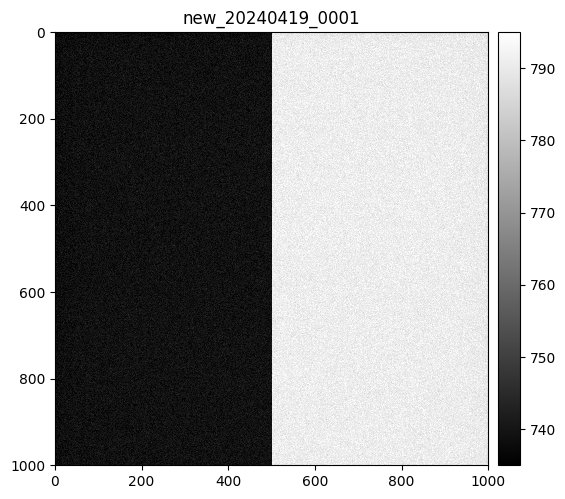

frame: /content/drive/MyDrive/M57/20240419/20240419_0002.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

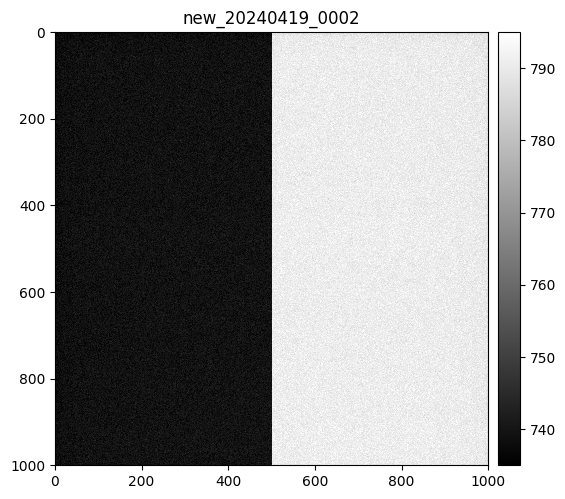

frame: /content/drive/MyDrive/M57/20240419/20240419_0003.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

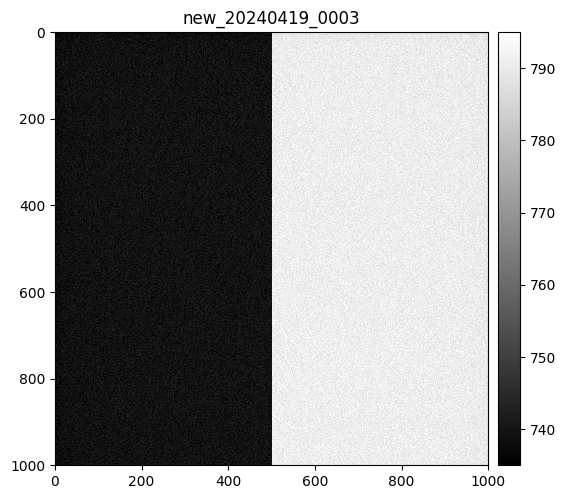

frame: /content/drive/MyDrive/M57/20240419/20240419_0004.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

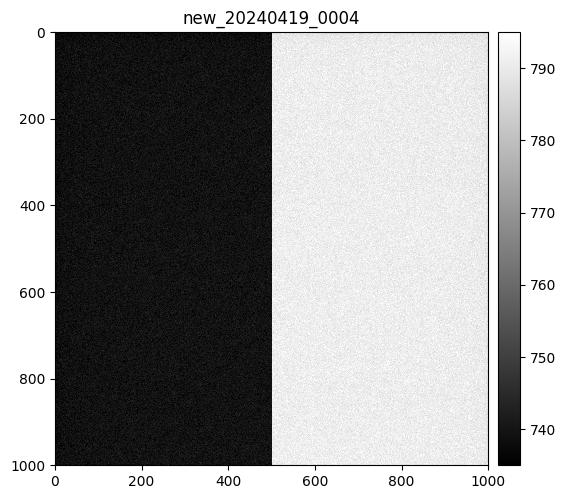

frame: /content/drive/MyDrive/M57/20240419/20240419_0005.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

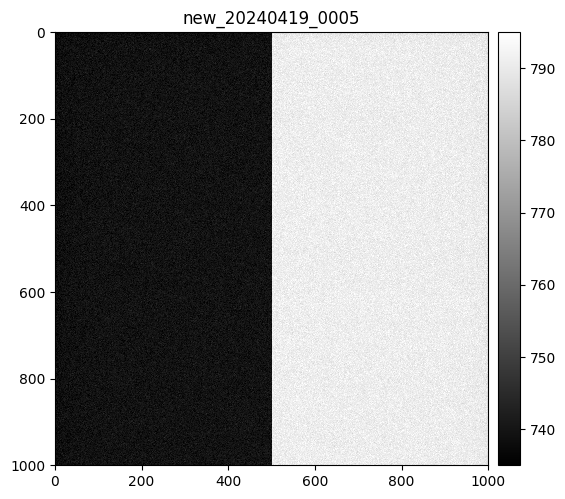

frame: /content/drive/MyDrive/M57/20240419/20240419_0006.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

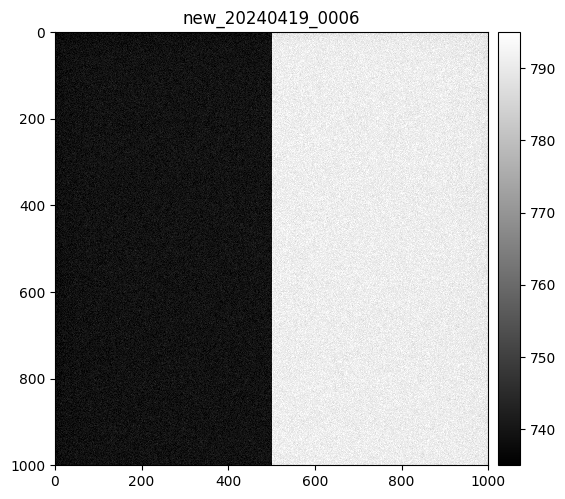

frame: /content/drive/MyDrive/M57/20240419/20240419_0007.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

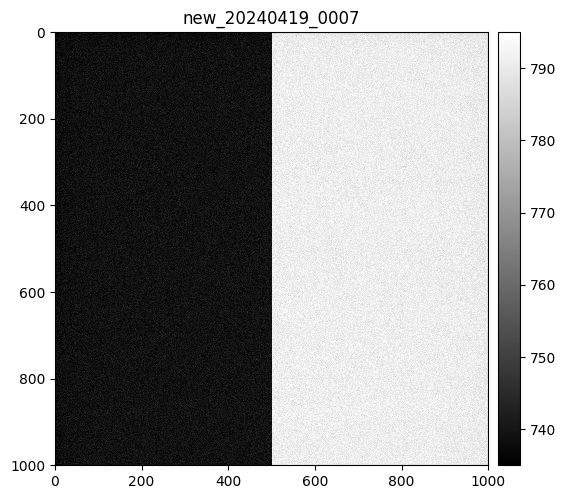

frame: /content/drive/MyDrive/M57/20240419/20240419_0008.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

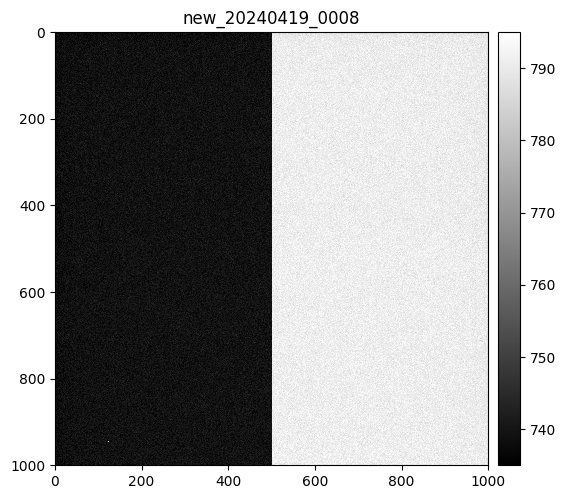

frame: /content/drive/MyDrive/M57/20240419/20240419_0009.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

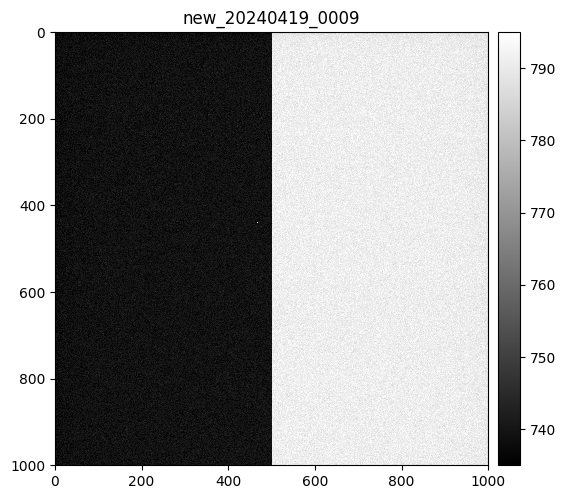

frame: /content/drive/MyDrive/M57/20240419/20240419_0010.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


<Figure size 640x480 with 0 Axes>

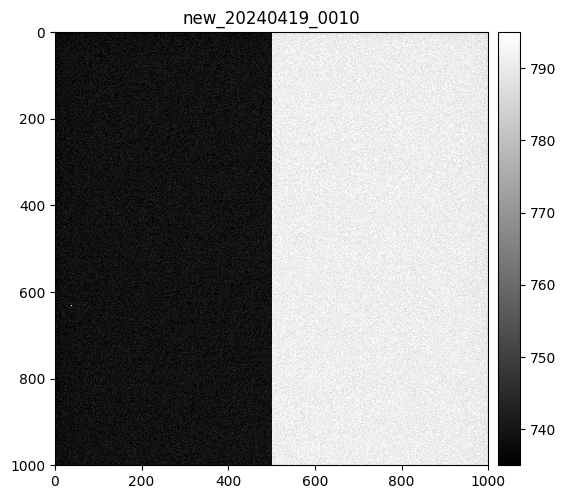

<Figure size 640x480 with 0 Axes>

In [ ]:
#create a bias list
bias_list= []
filename_list = []

#loop over the file list
for filename in ic.files_filtered(im_style='Bias'):

    #redefine the image name
    frame = ic.location+filename
    print('frame:', frame)

    #Read the data of the fits file as CCDData object
    ccd = CCDData.read(frame, unit = u.adu)
    print("image shape: ", ccd.shape)

    #trim the image from problematic columns and rows
    ccd = ccdproc.trim_image(ccd[y1:y2, x1:x2], add_keyword=True)
    print("image shape: ", ccd.shape)

    #write the trimmed image as a new fits file
    ccd.write('new_%s'%filename, overwrite=True)

    #open the new fits file with ccd modules
    ccd_new = CCDData.read('new_%s' %filename, unit = u.adu)

    #add the new image to the bias list
    bias_list.append(ccd_new)
    filename_list.append(filename[:-5])

    # plot the images
    # Read the image and its header
    # Convert to floating point for easier work later
    image = fits.getdata('new_%s' %filename).astype(np.double)
    header = fits.getheader('new_%s' %filename)
    plt.figure(figsize=(6, 6))
    plots.imshow(image, [0.5, 99.7], interpolation='nearest')
    plt.xlim(0, 1000)
    plt.ylim(1000, 0)
    plt.title('new_%s' %filename[:-5])
    plt.savefig('new_%s' %filename[:-5])
    plt.show()
    plt.clf()

## Creating and Visualizing Master Bias Frames

We combine the processed bias frames into a master bias frame. This master bias frame is essential for correcting systematic electronic noise across all images in our dataset.

- **Counting Bias Frames**: We print the number of bias frames processed and stored in `bias_list` and `filename_list`. This provides a quick check to ensure all expected frames have been included.

- **Combining Bias Frames**: We use the `ccdproc.combine` function to create a master bias frame by taking the median of all bias frames in `bias_list`. This method effectively reduces random noise and enhances the reliability of the bias correction.

- **Saving the Master Bias Frame**: The resulting master bias frame is saved as a FITS file named `master_bias.fits`, prefixed with `dir_name` to maintain consistency with our dataset.

- **Organizing Processed Files**: We move the newly created bias frames to the output directory (`outdir`) to keep our workspace organized and ensure that all processed files are stored systematically.

- **Visualizing the Master Bias Frame**:
  - We load the master bias frame data and its header, converting the data to floating-point for enhanced processing accuracy.
  - The master bias frame is visualized using `plots.imshow`, with specific percentile limits to highlight the frame's features.
  - The visualization is saved and displayed, providing a visual confirmation of the successful combination of bias frames.

                         
len(bias_list):  10
len(filename_list):  10
filename_list:  ['20240419_0001', '20240419_0002', '20240419_0003', '20240419_0004', '20240419_0005', '20240419_0006', '20240419_0007', '20240419_0008', '20240419_0009', '20240419_0010']
                         
Combining bias frames ...
                         
Done                     
                         


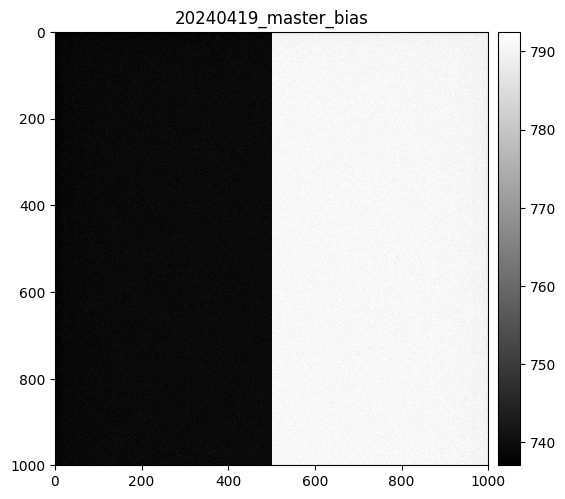

<Figure size 640x480 with 0 Axes>

In [ ]:
#number of bias frames
print('                         ')
#print('bias_list: ', bias_list)
print('len(bias_list): ', len(bias_list))

print('len(filename_list): ', len(filename_list))
print('filename_list: ', filename_list)

print('                         ')
print('Combining bias frames ...')

#create the master bias
master_bias = ccdproc.combine(bias_list, method='median')
#master_bias = ccdproc.combine(bias_list[0:9], method='median')
print('                         ')
print('Done                     ')
print('                         ')

#write the final frame as a fits file
master_bias.write('%s_master_bias.fits' %(dir_name), overwrite=True)

#move the new bias frames to another dir
os.system('mv new_* %s' %(outdir))

# plot the images
# Read the image and its header
# Convert to floating point for easier work later
image = fits.getdata('%s_master_bias.fits' %(dir_name)).astype(np.double)
header = fits.getheader('%s_master_bias.fits' %(dir_name))
plt.figure(figsize=(6, 6))
plots.imshow(image, [0.5, 99.7], interpolation='nearest')
plt.xlim(0, 1000)
plt.ylim(1000, 0)
plt.title('%s_master_bias' %(dir_name))
plt.savefig('%s_master_bias' %(dir_name))
plt.show()
plt.clf()


## Loading the Master Bias Frame

In this step, we load the master bias frame that we previously saved as a FITS file. This frame is crucial for the subsequent data reduction steps, as it will be used to correct the raw images for electronic noise.

- **Loading the Master Bias**: We read the master bias frame from the FITS file using `CCDData.read`, specifying the unit as `adu` (analog-to-digital units). This ensures that the data is correctly interpreted and ready for use in further processing.

In [ ]:
master_bias = CCDData.read('%s_master_bias.fits' %(dir_name), unit = u.adu)

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


## Setting Observation Parameters For Flat field frames

In this section, we define key parameters related to the observations, which are essential for accurate data analysis and interpretation.

- **Filter Name**: We set the `filter_name` variable to `'V'`, indicating that the observations were made using the V-band filter.

- **Exposure Time**: We define the `exposure_time` variable as `14.50` seconds.


In [ ]:
filter_name = 'V' #for flat frames
print('filter_name: ', filter_name)

#define the exposure time for the flat frames
exposure_time = 14.50
print('exposure_time: ', exposure_time)

filter_name:  V
exposure_time:  14.5


## Creating and Processing Flat Field Frames

In this section, we compile and process a list of flat field frames, which are essential for correcting variations in pixel sensitivity across the CCD detector. Flat field frames help ensure uniformity in the photometric data by accounting for these variations.

- **Initialize Lists**: We start by initializing `flat_filter_list` to store processed flat field frames and `scale_factor_list` to keep track of scaling factors based on the mean pixel values.

- **Iterate Over Flat Field Files**: We loop through all files identified as flat field frames using the `files_filtered` method with `im_style='Light'`, `exptime` matching the defined `exposure_time`, and `filter` set to `filter_name`. This filters and selects only the relevant flat field frames from our collection.

- **Read and Process FITS Files**:
  - For each file, we construct the full file path and read the image data into a `CCDData` object, specifying the unit as `adu`.
  - We print the original shape of the image and then trim it using `ccdproc.trim_image` to remove any problematic rows and columns, keeping only the defined region of interest (`y1:y2, x1:x2`).
  - We write the trimmed image to a new FITS file and subsequently read it back using `CCDData.read`.

- **Subtract Master Bias**: We subtract the master bias frame from each flat field frame to correct for electronic noise.

- **Create Scale List**: We calculate the scale factor for each frame as the inverse of its mean pixel value and append it to `scale_factor_list`.

- **Create Flat Field List**: The processed `CCDData` object is added to `flat_filter_list`, organizing our processed data.

- **Visualize Images**:
  - We load the image data and header, convert the data to floating-point for accuracy, and visualize it using `plots.imshow`. The visualization is configured with specific percentile limits to enhance visibility.
  - Each image is plotted, saved, and displayed using Matplotlib, providing a visual confirmation of the flat field frame processing.

By compiling and processing flat field frames in this manner, we prepare them for subsequent steps in the photometric reduction pipeline, ensuring that our data is corrected for pixel sensitivity variations.

frame: /content/drive/MyDrive/M57/20240419/20240419_0127.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
ccd_new_mean 24152


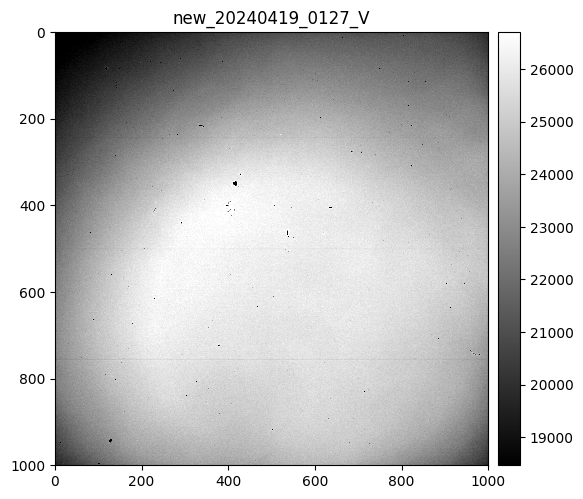

frame: /content/drive/MyDrive/M57/20240419/20240419_0128.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
ccd_new_mean 24165


<Figure size 640x480 with 0 Axes>

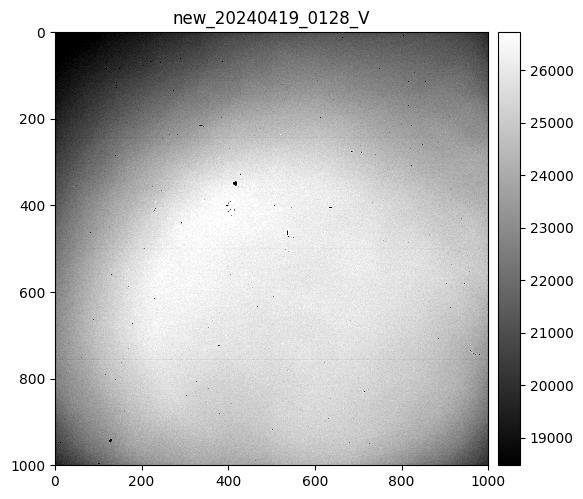

frame: /content/drive/MyDrive/M57/20240419/20240419_0129.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
ccd_new_mean 24179


<Figure size 640x480 with 0 Axes>

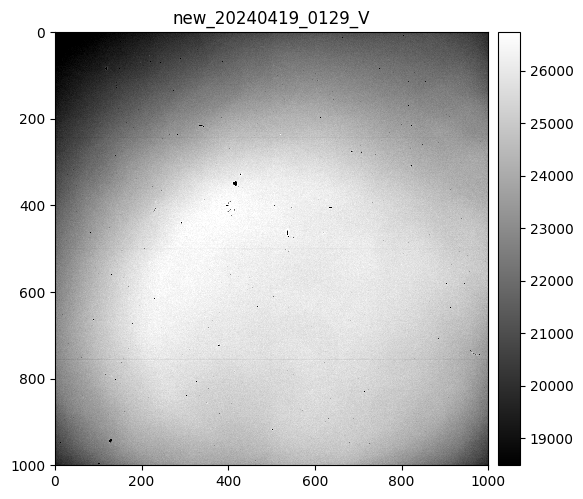

frame: /content/drive/MyDrive/M57/20240419/20240419_0130.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
ccd_new_mean 24189


<Figure size 640x480 with 0 Axes>

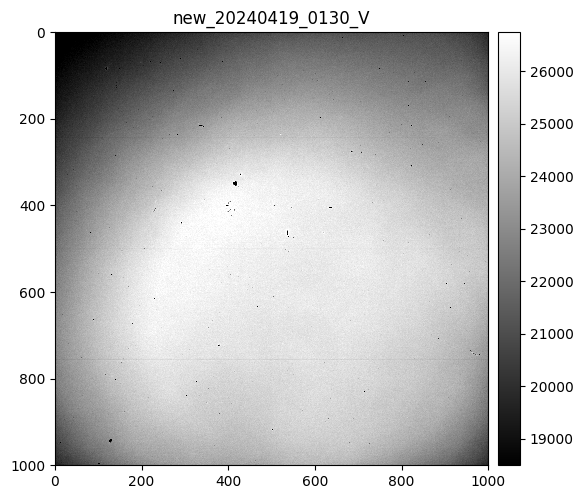

frame: /content/drive/MyDrive/M57/20240419/20240419_0131.fits


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
ccd_new_mean 24202


<Figure size 640x480 with 0 Axes>

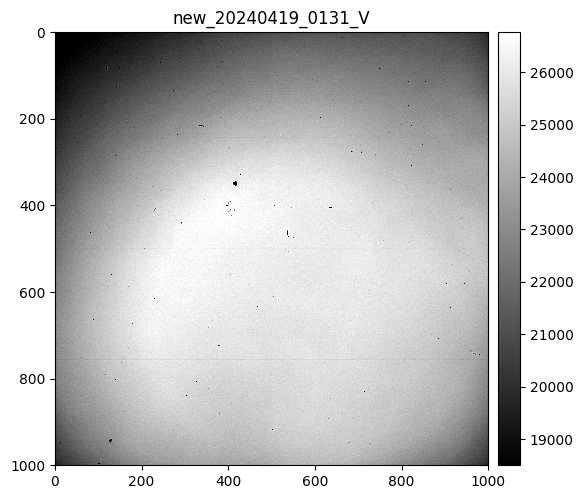

<Figure size 640x480 with 0 Axes>

In [ ]:
#create a list from flat field frames with thier scales (mean)
flat_filter_list  = []
scale_factor_list = []

#loop over the file list
for filename in ic.files_filtered(im_style='Light',
                                  exptime='%s'%exposure_time,
                                  filter= filter_name):

    #redefine the image name
    frame = ic.location+filename
    print('frame:', frame)

    #Read the data of the fits file as CCDData object
    ccd = CCDData.read(frame, unit = u.adu)
    print("image shape: ", ccd.shape)

    #trim the image from problematic columns and rows
    ccd = ccdproc.trim_image(ccd[y1:y2, x1:x2], add_keyword=True)
    print("image shape: ", ccd.shape)

    #write the trimmed image as a new fits file
    ccd.write('new_%s'%filename, overwrite=True)

    #open the new fits file with ccd modules
    ccd_new = CCDData.read('new_%s' %filename, unit = u.adu)

    #exclude images with low OR saturated pixels
    #mean_value = int(round(np.mean(ccd_new), 0))
    mean_value = int(round(np.mean(ccd_new.data), 0))
    print('ccd_new_mean', mean_value)

    #if (20000. < mean_value < 50000.):

    #subtract master bias
    ccd_new = ccdproc.subtract_bias(ccd_new, master_bias)

    #create the scale list
    scale_factor_list.append(1.0/mean_value)

    #create a list
    flat_filter_list.append(ccd_new)

    # plot the images
    # Read the image and its header
    # Convert to floating point for easier work later
    image = fits.getdata('new_%s' %filename).astype(np.double)
    header = fits.getheader('new_%s' %filename)
    plt.figure(figsize=(6, 6))
    plots.imshow(image, [0.5, 99.7], interpolation='nearest')
    plt.xlim(0, 1000)
    plt.ylim(1000, 0)
    plt.title('new_%s_%s' %(filename[:-5],filter_name))
    plt.savefig('new_%s' %filename[:-5])
    plt.show()
    plt.clf()

## Creating and Visualizing Master Flat Field Frames

We combine the processed flat field frames into a master flat frame. This master flat frame is essential for correcting variations in pixel sensitivity across the CCD detector, ensuring uniformity in the photometric data.

- **Counting Flat Field Frames**: We print the number of flat field frames processed and stored in `flat_filter_list` and `scale_factor_list`. This provides a quick check to ensure all expected frames have been included.

- **Combining Flat Frames**: We use the `ccdproc.combine` function to create a master flat frame by taking the median of all flat field frames in `flat_filter_list`, scaled by `scale_factor_list`. This method effectively reduces random noise and enhances the reliability of the flat field correction.

- **Saving the Master Flat Frame**: The resulting master flat frame is saved as a FITS file named `master_flat.fits`, prefixed with `dir_name` and suffixed with `filter_name` to maintain consistency with our dataset.




                         
len(flat_filter_list):    5
len(scale_factor_list):   5
                         
Combining flat frames ...
                         
Done                     
                         


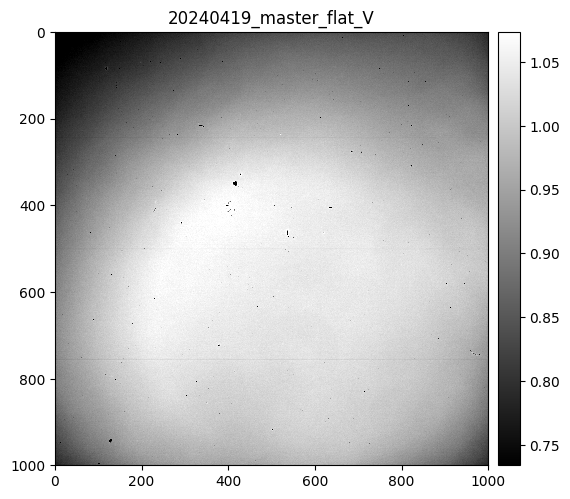

<Figure size 640x480 with 0 Axes>

In [ ]:
#number of flat field frames
print('                         ')
print("len(flat_filter_list):   ", len(flat_filter_list))
print("len(scale_factor_list):  ", len(scale_factor_list))
print('                         ')
print('Combining flat frames ...')

#create the master flat
master_flat = ccdproc.combine(flat_filter_list,
                              method='median',
                              scale=scale_factor_list)

print('                         ')
print('Done                     ')
print('                         ')

#write the final frame as a fits file
master_flat.write('%s_master_flat_%s.fits'%(dir_name, filter_name), overwrite=True)

#move the new flat frames to another dir
os.system('mv new_* %s' %(outdir))

# plot the images
# Read the image and its header
# Convert to floating point for easier work later
image = fits.getdata('%s_master_flat_%s.fits' %(dir_name,filter_name)).astype(np.double)
header = fits.getheader('%s_master_flat_%s.fits' %(dir_name,filter_name))
plt.figure(figsize=(6, 6))
plots.imshow(image, [0.5, 99.7], interpolation='nearest')
plt.xlim(0, 1000)
plt.ylim(1000, 0)
plt.title('%s_master_flat_%s' %(dir_name,filter_name))
plt.savefig('%s_master_flat_%s' %(dir_name,filter_name))
plt.show()
plt.clf()


## Loading the Master Flat Frame

In this step, we load the master flat frame that we previously saved as a FITS file. This frame is crucial for the subsequent data reduction steps, as it will be used to correct the raw images for variations in pixel sensitivity.

- **Loading the Master Flat**: We read the master flat frame from the FITS file using `CCDData.read`, specifying the unit as `adu` (analog-to-digital units). This ensures that the data is correctly interpreted and ready for use in further processing.

In [ ]:
master_flat = CCDData.read('%s_master_flat_%s.fits'%(dir_name, filter_name), unit = u.adu)

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


## Setting Observation Parameters For the Science Frames

In this section, we define parameters related to the science frames, which are essential for accurate data analysis and interpretation.

- **Exposure Time**: We define the `exposure_time` variable as `60.0` seconds.

- **Object Name**: We set the `object_name` variable to `'M57'`, which corresponds to the name of the astronomical object observed, as recorded in the FITS header. This helps in organizing and identifying the data associated with specific celestial targets.


In [ ]:
#define the exposure time
exposure_time = 60.0

#write the object name as in the fits header
object_name = 'M57'

## Processing and Reducing Science Frames

In this section, we process and clean the science frames, which are the primary images of the astronomical object of interest. This involves several steps to ensure the data is free from artifacts and ready for analysis.

- **Initialize Lists**: We start by initializing `obj_filter_list` to store processed science frames and `filename_list` to keep track of filenames for reference.

- **Iterate Over Science Files**: We loop through all files identified as science frames using the `files_filtered` method with `im_style='Light'`, `object` set to `object_name`, `exptime` matching the defined `exposure_time`, and `filter` set to `filter_name`. This filters and selects only the relevant science frames from our collection.

- **Read and Process FITS Files**:
  - For each file, we construct the full file path and read the image data into a `CCDData` object, specifying the unit as `adu`.
  - We print the original shape of the image and then trim it using `ccdproc.trim_image` to remove any problematic rows and columns, keeping only the defined region of interest (`y1:y2, x1:x2`).
  - We write the trimmed image to a new FITS file and subsequently read it back using `CCDData.read`.

- **Subtract Master Bias and Correct for Flat Field**: We subtract the master bias frame and apply flat field correction to each science frame to correct for electronic noise and pixel sensitivity variations.

- **Remove Cosmic Rays**: We use the `astroscrappy.detect_cosmics` function to identify and remove cosmic rays from the image data. This step is crucial for ensuring that transient artifacts do not affect the analysis.

- **Save Cleaned Images**: We add a comment to the FITS header about cosmic ray removal and save the cleaned image with the updated header. The cleaned image is appended to `obj_filter_list`, and the filename is recorded in `filename_list`.

By processing and cleaning the science frames in this manner, we prepare them for accurate photometric analysis, ensuring that the data is free from artifacts and ready for further study.

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


filename:  20240419_0054.fits
frame: /content/drive/MyDrive/M57/20240419/20240419_0054.fits
image shape:  (1024, 1024)
image shape:  (1000, 1000)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Cosmic Rays removed and saved as: /content/drive/MyDrive/Reduced_files/V_20240419_0054.fits


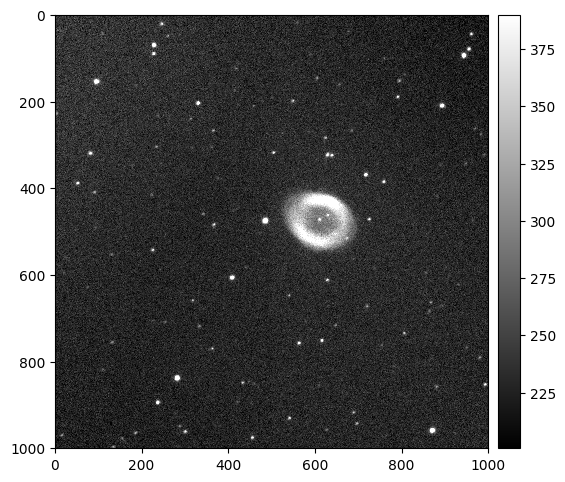

len(obj_filter_list): 1
                         
len(filename_list):  1
filename_list:  ['20240419_0054']


0

In [ ]:
obj_filter_list = []
filename_list = []

for filename in ic.files_filtered(im_style='Light',
                                  object='%s' % object_name,
                                  exptime='%s' % exposure_time,
                                  filter=filter_name):
    print('filename: ', filename)

    # Redefine the image name
    frame = ic.location + filename
    print('frame:', frame)

    # Read the data of the fits file as CCDData object
    ccd = CCDData.read(frame, unit=u.adu)
    print("image shape: ", ccd.shape)

    # Trim the image from problematic columns and rows
    ccd = ccdproc.trim_image(ccd[y1:y2, x1:x2], add_keyword=True)
    print("image shape: ", ccd.shape)

    # Write the trimmed image as a new fits file
    ccd.write('new_%s' % filename, overwrite=True)

    # Open the new fits file with CCD modules
    ccd_new = CCDData.read('new_%s' % filename, unit=u.adu)

    # Subtract master bias
    ccd_new = ccdproc.subtract_bias(ccd_new, master_bias)

    # Correct for flat field
    ccd_new = ccdproc.flat_correct(ccd_new, master_flat)

    # Convert CCDData object to numpy array for cosmic ray removal
    image_data = ccd_new.data
    header = ccd_new.header

    # Remove cosmic rays
    crmask, cleaned_data = astroscrappy.detect_cosmics(
        indat=image_data,
        sigclip=4.5,
        sigfrac=0.3,
        objlim=5.0,
        gain=2.14,
        readnoise=6.5,
        satlevel=65536.0,
        niter=10,
        sepmed=True,
        cleantype='meanmask',
        fsmode='median',
        psfmodel='gauss',
        psffwhm=2.5,
        psfsize=7,
        verbose=False
    )

    # Add a comment to the header about cosmic ray removal
    header['COMMENT'] = 'Cosmic rays removed using astroscrappy.'

    # Define final output file path in the outdir
    cleaned_frame = os.path.join(outdir, f"{filter_name}_{filename}")

    # Save the cleaned image with the updated header
    fits.writeto(cleaned_frame, cleaned_data, header=header, overwrite=True)

    print(f'Cosmic Rays removed and saved as: {cleaned_frame}')

    # Append the cleaned image to the list of corrected science frames
    obj_filter_list.append(ccd_new)
    filename_list.append(os.path.splitext(filename)[0])

    # Load the cleaned image for plotting
    image = fits.getdata(cleaned_frame).astype(np.double)

    # Plot the cleaned image
    plt.figure(figsize=(6, 6))
    plots.imshow(image, [0.5, 99.7], interpolation='nearest')
    plt.xlim(0, 1000)
    plt.ylim(1000, 0)
    plt.savefig(os.path.join(outdir, os.path.splitext(filename)[0]))
    plt.show()
    plt.clf()
    plt.close()

# Number of science frames
print("len(obj_filter_list):", len(obj_filter_list))
print('                         ')
print('len(filename_list): ', len(filename_list))
print('filename_list: ', filename_list)

# Move the new science frames to another directory
os.system(f'mv new_* {outdir}')

# **Visualizing Image Reduction: Before and After**  

This section presents a visual comparison of astronomical images before and after the data reduction process. The comparison helps illustrate the effectiveness of the reduction techniques applied.

## **Steps in the Visualization Process**  

1. **Loading Images**  
   - The **before** image is the raw science frame.  
   - The **after** image is the processed frame, following bias subtraction, flat fielding, and cosmic ray removal.  
   - Images are loaded using `fits.getdata` and converted to floating-point format for precise visualization.  

2. **Creating Side-by-Side Subplots**  
   - A figure with two subplots is generated to enable a direct visual comparison of the raw and reduced images.  


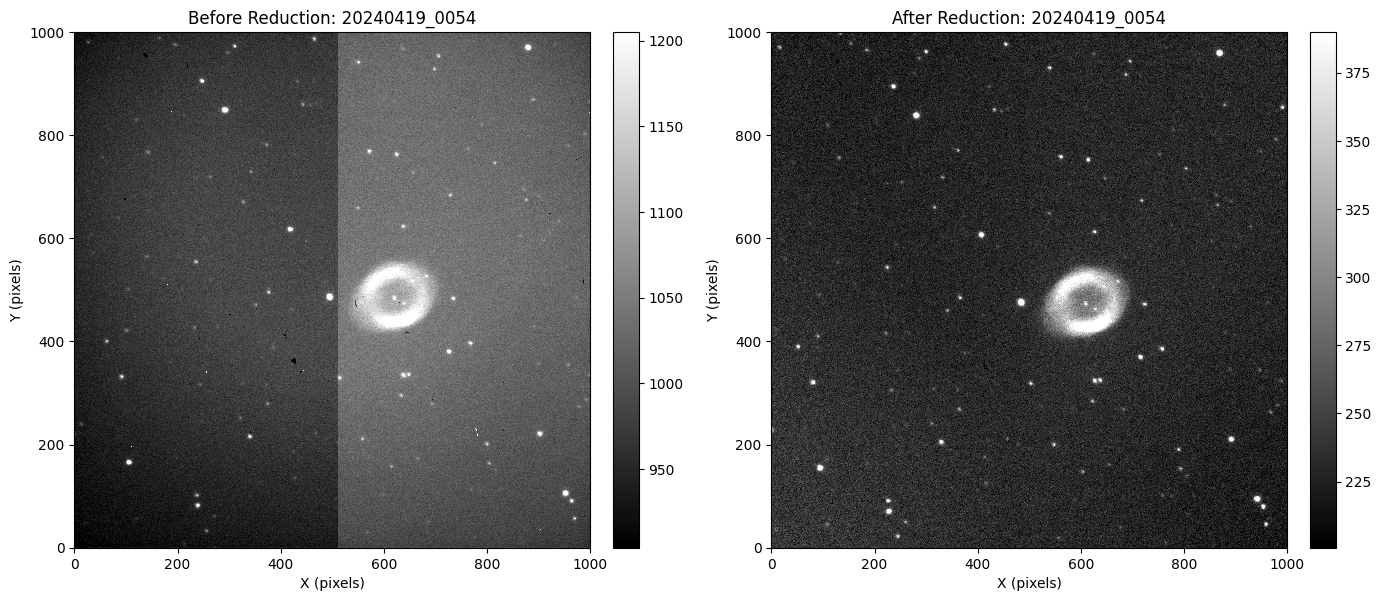

In [ ]:
for filename in filename_list:
    image_after_path = os.path.join(outdir, f"{filter_name}_{filename}.fits")  # After reduction
    image_before_path = os.path.join(indir, f"{filename}.fits")  # Original

    # Load the images
    image_after = fits.getdata(image_after_path).astype(np.double)
    image_before = fits.getdata(image_before_path).astype(np.double)

    # Create a figure with side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot the "before" image
    im_before = axes[0].imshow(image_before, origin='lower',
                               vmin=np.percentile(image_before, 0.5),
                               vmax=np.percentile(image_before, 99.7),
                               interpolation='nearest', cmap='gray')
    axes[0].set_title(f'Before Reduction: {filename}')
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    axes[0].set_xlim(0, 1000)
    axes[0].set_ylim(0, 1000)  # Start from zero at the bottom

    # Add colorbar for "before" image
    fig.colorbar(im_before, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot the "after" image
    im_after = axes[1].imshow(image_after, origin='lower',
                              vmin=np.percentile(image_after, 0.5),
                              vmax=np.percentile(image_after, 99.7),
                              interpolation='nearest', cmap='gray')
    axes[1].set_title(f'After Reduction: {filename}')
    axes[1].set_xlabel('X (pixels)')
    axes[1].set_ylabel('Y (pixels)')
    axes[1].set_xlim(0, 1000)
    axes[1].set_ylim(0, 1000)  # Start from zero at the bottom

    # Add colorbar for "after" image
    fig.colorbar(im_after, ax=axes[1], fraction=0.046, pad=0.04)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.savefig(f'Comparison_{filename}.png', format='png')
    plt.show()

## Adding World Coordinate System (WCS) Information

In this section, we enhance the reduced FITS files by adding World Coordinate System (WCS) information. WCS is crucial for mapping pixel coordinates to celestial coordinates, enabling precise astrometric analysis.

- **Initialize Astrometry.net Client**: We set up the `AstrometryNet` client with an API key. This service is used to solve for WCS by matching the star patterns in the images to known celestial coordinates.

- **Identify Reduced Files**: We list all reduced FITS files in the specified directory (`outdir`) that match the filter name. These files are the targets for WCS calibration.

- **Loop Through Reduced Files**:
  - For each file, we construct the full file path and print a message indicating the start of WCS processing.
  - We submit the FITS file to Astrometry.net for WCS calibration using `solve_from_image`, which returns a WCS header.

- **Update FITS Header**:
  - We open the FITS file in update mode and add the WCS information to the header.
  - The updated header is saved, and a success message is printed.

- **Error Handling**: If WCS calibration fails for any file, an error message is printed, indicating the issue.

In [ ]:
# Initialize Astrometry.net client
ast = AstrometryNet()
ast.api_key = 'ilqvzsvwmibpwktk'  # Get your API key from Astrometry.net

# List of reduced files
reduced_files = [f for f in os.listdir(outdir) if f.endswith('.fits') and f.startswith(filter_name)]

# Loop through the reduced files and add WCS
for filename in reduced_files:
    file_path = os.path.join(outdir, filename)
    print(f"Processing WCS for: {file_path}")

    try:
        # Submit the FITS file for WCS calibration
        wcs_header = ast.solve_from_image(file_path, force_image_upload=True)

        # Update the FITS header with WCS information
        with fits.open(file_path, mode='update') as hdul:
            hdul[0].header.update(wcs_header)
            hdul.flush()

        print(f"WCS coordinates added successfully for {filename}!")

    except Exception as e:
        print(f"Failed to add WCS to {filename}: {e}")


Processing WCS for: /content/drive/MyDrive/Reduced_files/V_20240419_0054.fits
Solving...........WCS coordinates added successfully for V_20240419_0054.fits!


## Visualizing Image Data in Pixel and WCS Scales

In this section, we visualize the image data in both pixel and World Coordinate System (WCS) scales. This dual visualization helps in understanding the spatial distribution of the data in both image and celestial coordinates.

- **Load Image Data and WCS**: We open the FITS file to extract the image data and WCS information. The WCS allows us to map pixel positions to celestial coordinates.

- **Create Side-by-Side Subplots**: We create a figure with two subplots to display the image data in both pixel and WCS scales.

- **Plot in Pixel Scale**:
  - The left subplot displays the image in pixel coordinates using `imshow`.

- **Plot in WCS Scale**:
  - The right subplot displays the image in WCS coordinates using `imshow` with a WCS projection.
  - A grid is added to the WCS plot to indicate celestial coordinates, with labels for Right Ascension (RA) and Declination (Dec).

By visualizing the image data in both pixel and WCS scales, we gain insights into the spatial distribution of the data, facilitating accurate interpretation and analysis in both image and celestial contexts.

a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


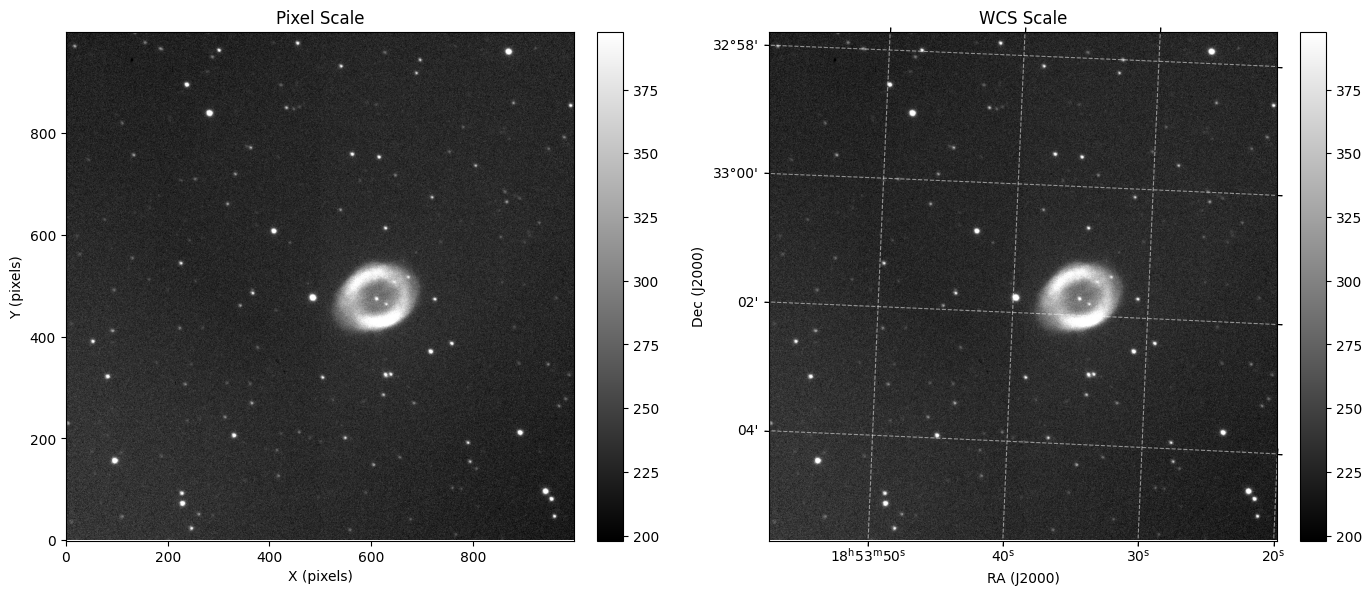

In [ ]:
# Load the FITS file and get the data and WCS
reduced_filename = os.path.join(outdir, f"{filename}")
with fits.open(reduced_filename) as hdul:
    data = hdul[0].data
    wcs = WCS(hdul[0].header)

# Normalize the image data for better visualization
norm = ImageNormalize(data, interval=PercentileInterval(99.5))  # Adjust percentile as needed

# Create a figure with side-by-side subplots
fig = plt.figure(figsize=(14, 6))

# Plot in pixel scale (left)
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(data, cmap='gray', norm=norm, origin='lower')
ax1.set_title("Pixel Scale")
ax1.set_xlabel("X (pixels)")
ax1.set_ylabel("Y (pixels)")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot in WCS scale (right)
ax2 = fig.add_subplot(1, 2, 2, projection=wcs)  # Explicitly set WCS projection
im2 = ax2.imshow(data, cmap='gray', norm=norm, origin='lower')
ax2.set_title("WCS Scale")
ax2.coords.grid(color='white', ls='--', alpha=0.5)  # Add WCS grid
ax2.coords[0].set_axislabel("RA (J2000)")
ax2.coords[1].set_axislabel("Dec (J2000)")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('Pixel_vs_WCS', format='png')
plt.show()

**Congratulations** on completing the photometric data reduction tutorial!

Throughout this notebook, you have learned how to process astronomical images by performing essential steps such as bias subtraction, flat field correction, cosmic ray removal, and WCS calibration. These techniques are crucial for ensuring the accuracy and reliability of photometric data, enabling precise scientific analysis.

### Assignment

To further develop your skills, complete the following assignment:

- **Data Reduction with a Different Filter**: Select a set of astronomical images taken with a different filter (e.g., B-band or R-band) from the one used in this tutorial. Apply the data reduction techniques you learned, including bias subtraction, flat field correction, and cosmic ray removal. Document each step and compare the results before and after reduction.

By completing this assignment, you will gain hands-on experience with photometric data reduction across different filters, enhancing your skills in astronomical data analysis.

### Next Steps

To continue your journey in astronomical data analysis, proceed to the [Photometry Technique Tutorial](https://colab.research.google.com/drive/1TLDj_4qDC5N5pycZ4sZk2yijlS0-7L8l?authuser=1#scrollTo=REngF3O9DI1P). This tutorial will guide you through the process of measuring the brightness of celestial objects and calibrating your data using advanced photometric techniques.

Good luck, and enjoy your exploration of the universe ^ ^